In [1]:
from causal_learn.causallearn.utils.cit import CIT
from causal_learn.causallearn.search.ConstraintBased.PC import pc
import numpy as np

def _binary_all(X_true):
    X = X_true.copy()
    for i in range(X.shape[1]):
        x_tmp = X[:,i]
        var = np.var(x_tmp)
        c = np.median(x_tmp)
        print(f"Random variable: {i}, threshold: {c}")
        x_tmp = np.where(x_tmp > c, 1, 0)
        X[:,i] = x_tmp
    return X

Random variable: 0, threshold: 4.976628100707126
Random variable: 1, threshold: 8.034536063608222
Random variable: 2, threshold: 4.998346263036681


  0%|          | 0/3 [00:00<?, ?it/s]

Variance: [1.95531946]
Z-score: [15.96206367]
P-value: [0.]
Variance: [2.18738036]
Z-score: [5.82861154]
P-value: [5.58904345e-09]
Variance: [3.18325481]
Z-score: [-0.1591747]
P-value: [0.87353124]


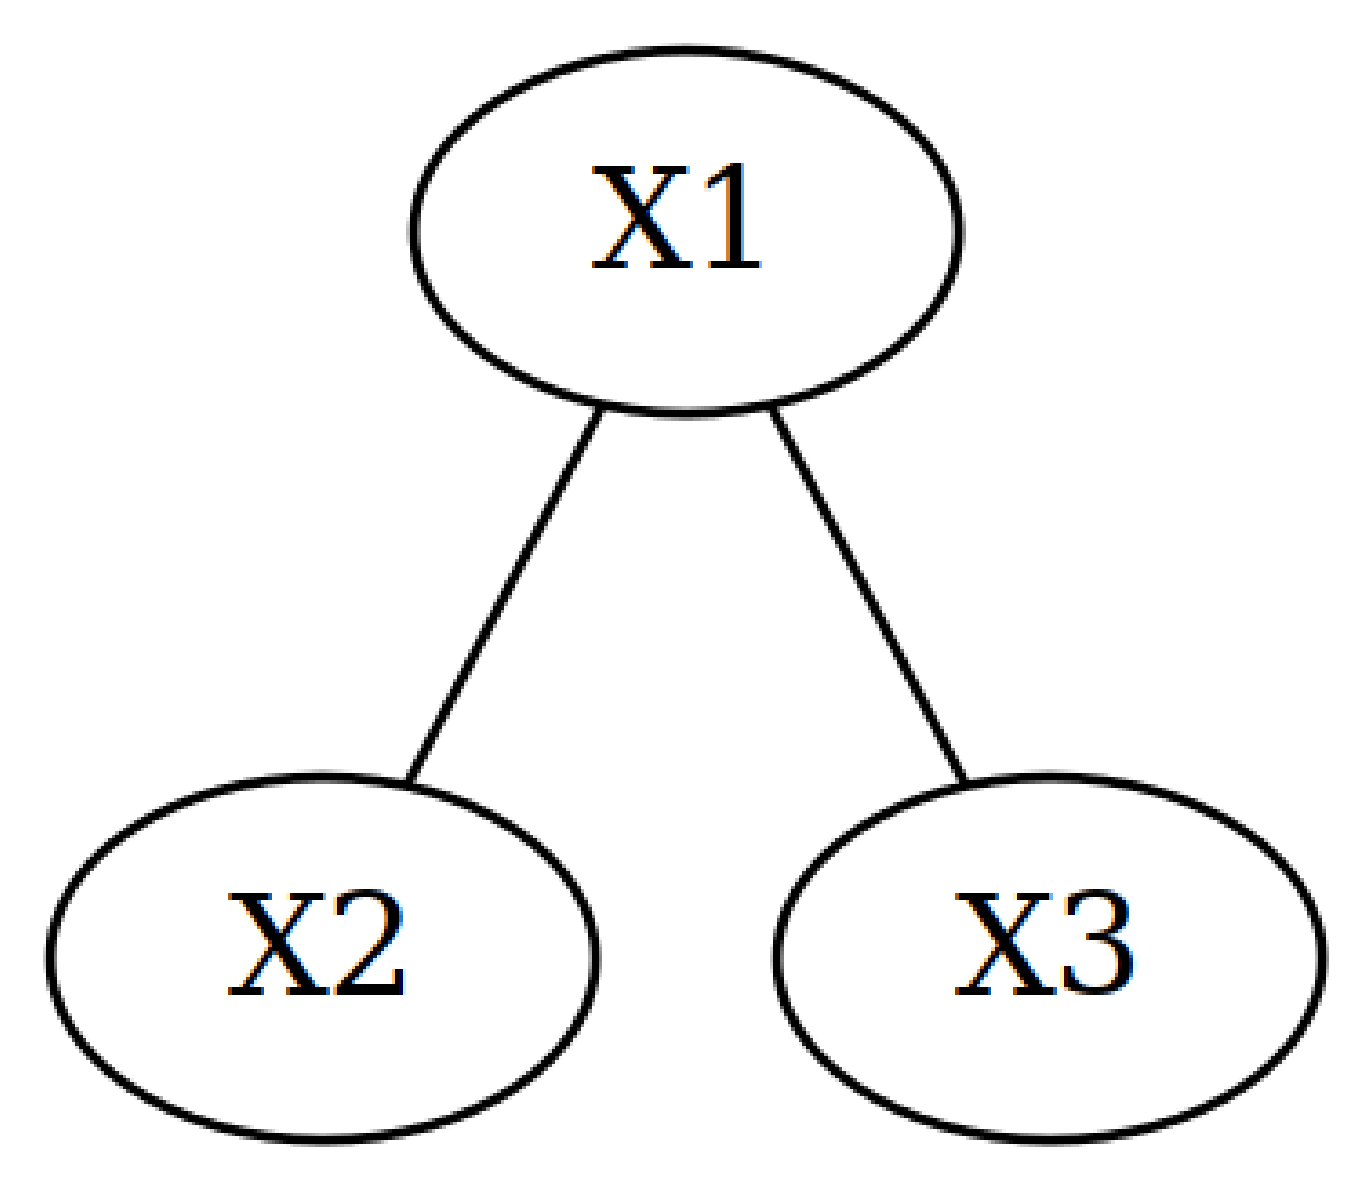

In [2]:
test = 'dis_test'

samples = 1000
x1 = np.random.normal(5,1,samples)
x2 = np.random.normal(-2,1,samples) + 2*x1
x3 = x1 + np.random.normal(0,1, samples)

X_true = np.array([x1, x2, x3]).T
data_bin = _binary_all(X_true)

cg = pc(data_bin, indep_test=test)

# visualization using pydot
cg.draw_pydot_graph()